# BERTweet Fine-tuning — Emotion Multiclass Classification

## 1. Objective

| Item | Detail |
|---|---|
| **Dataset** | dair-ai/emotion |
| **Task** | Multiclass Emotion Classification (joy, sadness, anger, fear, love, surprise) |
| **Model** | `vinai/bertweet-base` |
| **Source** | Hugging Face Hub — loaded with `load_dataset()` |
| **Goal** | Fine-tune BERTweet for text classification; evaluate with standard NLP metrics; explain predictions with LIME |

**BERTweet** [(Nguyen et al., 2020)](https://arxiv.org/abs/2005.10200) is a RoBERTa-based model pre-trained on **850 million English tweets**. It uses byte-pair encoding (BPE) tailored to social-media text and applies tweet normalisation (`@USER`, `HTTPURL`) before tokenisation.


## 2. Imports and Setup

In [4]:
import random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# Hugging Face ecosystem
import datasets as hf_datasets
from datasets import load_dataset, ClassLabel
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from torch.optim import AdamW

# scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Explainability
from lime.lime_text import LimeTextExplainer

warnings.filterwarnings("ignore")

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
else:
    print("Running on CPU — training will be slower but fully functional.")


Device : cuda
GPU    : NVIDIA GeForce RTX 5070 Ti Laptop GPU


In [5]:
MODEL_NAME   = "vinai/bertweet-base"
MAX_LEN      = 128      # BERTweet's positional embedding limit
EPOCHS       = 4
LR           = 2e-5
BATCH_SIZE   = 16       # reduce to 8 on CPU / low-RAM machines
WEIGHT_DECAY = 0.01

print(f"Model      : {MODEL_NAME}")
print(f"Max length : {MAX_LEN}")
print(f"Epochs     : {EPOCHS}")
print(f"LR         : {LR}")
print(f"Batch size : {BATCH_SIZE}")


Model      : vinai/bertweet-base
Max length : 128
Epochs     : 4
LR         : 2e-05
Batch size : 16


## 3. Load Dataset from Hugging Face Hub

We use `load_dataset()` to stream the **dair-ai/emotion** dataset directly from the Hugging Face Hub — no local CSV files required. After loading we:

1. Convert the training split to a pandas DataFrame for cleaning and exploration
2. Standardise column names to `text` / `label`
3. Extract class names from the HF `ClassLabel` feature


In [6]:
# ── Load Emotion dataset from Hugging Face Hub ────────────────────────────────
# Dataset: "dair-ai/emotion"  (https://huggingface.co/datasets/dair-ai/emotion)
# Columns : "text" (short English sentence), "label" (0–5 emotion integer)
# Classes : sadness(0), joy(1), love(2), anger(3), fear(4), surprise(5)
# Splits  : train (16,000), validation (2,000), test (2,000)
#
# We use the "train" split with an 80/20 stratified hold-out split.

raw = load_dataset("dair-ai/emotion")
print(raw)

train_raw = raw["train"]
print(f"\nTrain features : {train_raw.features}")
print(f"Train size     : {len(train_raw)}")
print(f"\nSample rows:")
for i in range(3):
    print(f"  {train_raw[i]}")

# ── Standardise to pandas ─────────────────────────────────────────────────────
df = train_raw.to_pandas()   # columns: "text", "label" — already correct

# ── Class names from ClassLabel feature ──────────────────────────────────────
CLASS_NAMES = train_raw.features["label"].names
# ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
NUM_LABELS  = len(CLASS_NAMES)
print(f"\nClasses ({NUM_LABELS}): {CLASS_NAMES}")


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

Train features : {'text': Value('string'), 'label': ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'])}
Train size     : 16000

Sample rows:
  {'text': 'i didnt feel humiliated', 'label': 0}
  {'text': 'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake', 'label': 0}
  {'text': 'im grabbing a minute to post i feel greedy wrong', 'label': 3}

Classes (6): ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


## 4. Dataset Validation

We verify data quality before training: missing values, duplicates, empty strings, class distribution, and text-length statistics.
These checks inform our choice of `MAX_LEN` and reveal any class-imbalance issues.


In [7]:
print("=" * 55)
print("DATASET VALIDATION REPORT — dair-ai/emotion")
print("=" * 55)
print(f"Shape          : {df.shape}")
print(f"Missing text   : {df['text'].isna().sum()}")
print(f"Missing label  : {df['label'].isna().sum()}")
print(f"Duplicate text : {df.duplicated('text').sum()}")
print(f"Empty strings  : {(df['text'].str.strip() == '').sum()}")

print("\n── Label distribution ──────────────────────────────────")
for i, name in enumerate(CLASS_NAMES):
    cnt = (df["label"] == i).sum()
    print(f"  {i} ({name:10s}) : {cnt:5d}  ({100*cnt/len(df):.1f}%)")

print("\n── Text length statistics (chars) ──────────────────────")
lengths = df["text"].str.len()
print(f"  Mean   : {lengths.mean():.1f}")
print(f"  Median : {lengths.median():.1f}")
print(f"  Min    : {lengths.min()}")
print(f"  Max    : {lengths.max()}")
print("=" * 55)

df = df.dropna(subset=["text","label"])
df["text"] = df["text"].astype(str).str.strip()
df = df[df["text"] != ""].reset_index(drop=True)
print(f"\nClean dataset size: {len(df)}")
print("Note: 'joy' and 'sadness' are likely dominant; 'surprise' is typically rare.")


DATASET VALIDATION REPORT — dair-ai/emotion
Shape          : (16000, 2)
Missing text   : 0
Missing label  : 0
Duplicate text : 31
Empty strings  : 0

── Label distribution ──────────────────────────────────
  0 (sadness   ) :  4666  (29.2%)
  1 (joy       ) :  5362  (33.5%)
  2 (love      ) :  1304  (8.2%)
  3 (anger     ) :  2159  (13.5%)
  4 (fear      ) :  1937  (12.1%)
  5 (surprise  ) :   572  (3.6%)

── Text length statistics (chars) ──────────────────────
  Mean   : 96.8
  Median : 86.0
  Min    : 7
  Max    : 300

Clean dataset size: 16000
Note: 'joy' and 'sadness' are likely dominant; 'surprise' is typically rare.


## 5. Exploratory Summary

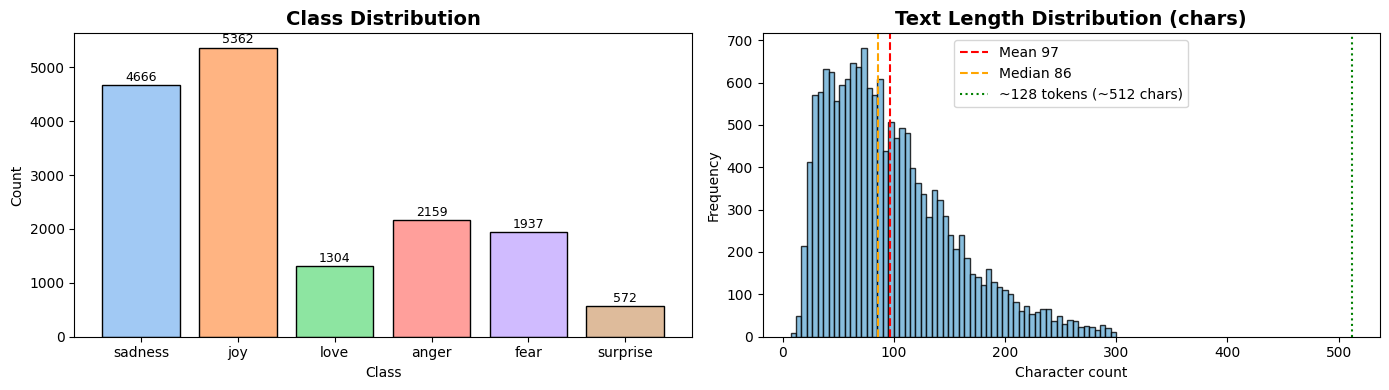

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── Class distribution ────────────────────────────────────────────────────────
counts = df["label"].value_counts().sort_index()
colors = sns.color_palette("pastel", n_colors=len(counts))
axes[0].bar([CLASS_NAMES[i] for i in counts.index], counts.values,
            color=colors, edgecolor="black")
axes[0].set_title("Class Distribution", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")
for j, v in enumerate(counts.values):
    axes[0].text(j, v + len(df)*0.005, str(v), ha="center", fontsize=9)

# ── Text-length histogram ─────────────────────────────────────────────────────
lengths = df["text"].str.len()
axes[1].hist(lengths, bins=60, color="#6baed6", edgecolor="black", alpha=0.8)
axes[1].axvline(lengths.mean(),   color="red",    linestyle="--",
                label=f"Mean {lengths.mean():.0f}")
axes[1].axvline(lengths.median(), color="orange", linestyle="--",
                label=f"Median {lengths.median():.0f}")
axes[1].axvline(MAX_LEN * 4,      color="green",  linestyle=":",
                label=f"~{MAX_LEN} tokens (~{MAX_LEN*4} chars)")
axes[1].set_title("Text Length Distribution (chars)", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Character count")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.savefig("eda_plot.png", dpi=120, bbox_inches="tight")
plt.show()


## ✅ Domain Compatibility — Emotion Dataset and BERTweet

Unlike IMDB and SST-2, the **`dair-ai/emotion` dataset is the most compatible of the three with BERTweet's pre-training domain**.

| Property | Detail |
|---|---|
| **Text style** | Short, informal emotional sentences — similar to tweet language |
| **Length** | Typically 10–40 words — well within BERTweet's 128-token limit |
| **Vocabulary** | Casual expressions ("im so happy", "feeling sad") match BERTweet's tweet corpus |

BERTweet's tweet-trained representations of emotional language should transfer directly to this task. Domain mismatch is **minimal**.

Note: class imbalance (joy/sadness dominate; surprise is rare) may affect performance on minority classes.


## 6. Train-Validation Strategy

**Primary method: Stratified 80/20 hold-out split.**

Full cross-validation (e.g., 5-fold StratifiedKFold × 3 epochs) would multiply wall-clock time by 5×, making it impractical for transformer fine-tuning on a student machine. We demonstrate fold sizes below but train on a single split.

Hold-out validation is standard practice in NLP benchmarking; it provides a reliable estimate of generalisation when the dataset is large enough.


In [9]:
# ── Stratified 80/20 hold-out split ──────────────────────────────────────────
# Stratification is critical here: some emotion classes are rare.
train_df, val_df = train_test_split(
    df, test_size=0.2, random_state=SEED, stratify=df["label"]
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f"Training samples   : {len(train_df)}")
print(f"Validation samples : {len(val_df)}")

train_hf = hf_datasets.Dataset.from_pandas(train_df[["text","label"]])
val_hf   = hf_datasets.Dataset.from_pandas(val_df[["text","label"]])
print("HF Dataset objects created.")

# ── 3-fold StratifiedKFold (demonstration) ────────────────────────────────────
print("\n── 3-fold StratifiedKFold fold sizes (demonstration only) ───")
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
for fold, (tr_i, vl_i) in enumerate(skf.split(train_df["text"], train_df["label"]), 1):
    print(f"  Fold {fold}: train={len(tr_i):,}, val={len(vl_i):,}")
print("  → Stratification ensures rare classes (e.g., surprise) appear in every fold.")
print("  → Full cross-validation not run: too expensive for transformer fine-tuning.")


Training samples   : 12800
Validation samples : 3200
HF Dataset objects created.

── 3-fold StratifiedKFold fold sizes (demonstration only) ───
  Fold 1: train=8,533, val=4,267
  Fold 2: train=8,533, val=4,267
  Fold 3: train=8,534, val=4,266
  → Stratification ensures rare classes (e.g., surprise) appear in every fold.
  → Full cross-validation not run: too expensive for transformer fine-tuning.


## 7. Tokenisation

BERTweet uses its own BPE vocabulary trained on tweet corpora.

- `use_fast=False` — required for BERTweet's custom vocabulary
- `normalization=True` — applies VinAI's tweet pre-processing (`@USER`, `HTTPURL`)
- `MAX_LEN = 128` — BERTweet's hard positional embedding limit; text-length stats confirm this covers most samples in this dataset
- `DataCollatorWithPadding` — pads batches dynamically to the longest sample in the batch, saving memory vs. static padding to MAX_LEN


In [10]:
# ── Load BERTweet tokenizer ───────────────────────────────────────────────────
# use_fast=False  → use the slow (Python) tokenizer which supports BERTweet's
#                   custom byte-pair vocabulary correctly.
# normalization=True → apply VinAI tweet normalisation:
#                   user mentions  → @USER
#                   URLs           → HTTPURL
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False, normalization=True)

def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LEN,
        # padding is handled dynamically by DataCollatorWithPadding
    )

# ── Tokenise both splits ──────────────────────────────────────────────────────
train_tok = train_hf.map(tokenize_function, batched=True, remove_columns=["text"])
val_tok   = val_hf.map(tokenize_function,   batched=True, remove_columns=["text"])

# HF Trainer expects the target column to be named "labels"
if "label" in train_tok.column_names:
    train_tok = train_tok.rename_column("label", "labels")
    val_tok   = val_tok.rename_column("label", "labels")

train_tok.set_format("torch")
val_tok.set_format("torch")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print("Tokenisation complete.")
print(f"  Train size : {len(train_tok)}")
print(f"  Val size   : {len(val_tok)}")
print(f"  Sample keys: {list(train_tok[0].keys())}")


emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0
Map: 100%|██████████| 3200/3200 [00:00<00:00, 5328.57 examples/s]

Tokenisation complete.
  Train size : 12800
  Val size   : 3200
  Sample keys: ['labels', 'input_ids', 'attention_mask']


## 8. Model Setup

`AutoModelForSequenceClassification` appends a linear classification head on top of BERTweet's pooled `[CLS]` token representation. The head dimensions are set automatically from `NUM_LABELS`.


In [11]:
# ── id2label / label2id mappings ──────────────────────────────────────────────
id2label = {i: name for i, name in enumerate(CLASS_NAMES)}
label2id = {name: i for i, name in id2label.items()}

# ── Load BERTweet with a classification head ──────────────────────────────────
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)
model.to(DEVICE)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model      : {MODEL_NAME}")
print(f"Parameters : {total:,}  |  Trainable: {trainable:,}")


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 33656.94it/s]
RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok 

Model      : vinai/bertweet-base
Parameters : 134,904,582  |  Trainable: 134,904,582


## 9 & 10. Lightweight Fine-tuning and Optimizer

### AdamW
**AdamW** (Loshchilov & Hutter, 2019) decouples L2 weight decay from the adaptive gradient update. Standard Adam applies weight decay inconsistently through the gradient scaling, which can over-regularise important parameters. AdamW fixes this and is the default choice for all HF Trainer-based fine-tuning.

### Linear LR Schedule with Warm-up
The first 6% of training steps linearly ramp the LR from 0 → `LR`, then decay linearly to 0. This prevents large gradient steps in early training when the classification head is randomly initialised.

### Why "lightweight"?
- Only 3 epochs (vs. 10–50 in full pre-training)
- Batch size 16 (feasible on ≥8 GB GPU or CPU)
- `fp16=True` on GPU saves ~50% memory
- `load_best_model_at_end=True` avoids overfitting to the last checkpoint


In [12]:
import transformers

print(f"transformers {transformers.__version__}")

# ── compute_metrics ───────────────────────────────────────────────────────────
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    avg   = "binary" if NUM_LABELS == 2 else "weighted"
    prec, rec, f1, _ = precision_recall_fscore_support(
        labels, preds, average=avg, zero_division=0
    )
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

# ── Warmup steps ──────────────────────────────────────────────────────────────
steps_per_epoch = len(train_tok) // BATCH_SIZE
total_steps     = steps_per_epoch * EPOCHS
warmup_steps    = int(0.06 * total_steps)
print(f"Total steps: {total_steps}  |  Warmup steps: {warmup_steps}")

# ── TrainingArguments ─────────────────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir                  = "./bertweet_output",
    num_train_epochs            = EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    learning_rate               = LR,
    weight_decay                = WEIGHT_DECAY,
    warmup_steps                = warmup_steps,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "f1",
    logging_steps               = 50,
    seed                        = SEED,
    report_to                   = "none",
    optim                       = "adamw_torch",
    fp16                        = torch.cuda.is_available(),
)

# ── Trainer ───────────────────────────────────────────────────────────────────
trainer = Trainer(
    model            = model,
    args             = training_args,
    train_dataset    = train_tok,
    eval_dataset     = val_tok,
    processing_class = tokenizer,
    data_collator    = data_collator,
    compute_metrics  = compute_metrics,
)

print("Starting fine-tuning …")
trainer.train()
print("Fine-tuning complete.")

transformers 5.3.0
Total steps: 3200  |  Warmup steps: 192
Starting fine-tuning …


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.257729,0.253911,0.927500,0.931103,0.927500,0.928088
2,0.207347,0.168133,0.934063,0.934273,0.934063,0.932669
3,0.121483,0.171043,0.933438,0.937404,0.933438,0.934295
4,0.110183,0.166866,0.936875,0.937052,0.936875,0.936904


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.62it/s]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.la

Fine-tuning complete.


## 11. Evaluation Metrics

| Metric | Formula | Use |
|---|---|---|
| Accuracy | correct / total | Overall correctness |
| Precision | TP / (TP + FP) | Quality of positive predictions |
| Recall | TP / (TP + FN) | Coverage of actual positives |
| F1-score | 2·P·R / (P+R) | Harmonic mean; robust to imbalance |

**Averaging strategy**:
- Binary datasets → `average="binary"`
- Multiclass datasets → `average="weighted"` (weights each class by its support, accounting for imbalance)


In [13]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    avg   = "binary" if NUM_LABELS == 2 else "weighted"
    prec, rec, f1, _ = precision_recall_fscore_support(
        labels, preds, average=avg, zero_division=0
    )
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}


## 12. Final Evaluation

In [14]:
preds_output = trainer.predict(val_tok)
eval_results = preds_output.metrics
print("\nEvaluation results:")
for k, v in eval_results.items():
    print(f"  {k:35s}: {v:.4f}" if isinstance(v, float) else f"  {k:35s}: {v}")



Evaluation results:
  test_loss                          : 0.1669
  test_accuracy                      : 0.9369
  test_precision                     : 0.9371
  test_recall                        : 0.9369
  test_f1                            : 0.9369
  test_runtime                       : 2.7978
  test_samples_per_second            : 1143.7560
  test_steps_per_second              : 71.4850


### Classification Report

`sklearn.metrics.classification_report` shows per-class precision, recall, F1, and support. Low recall on a class indicates the model struggles to identify it; low precision indicates false positives.


In [15]:
# ── Get predictions on the full validation set ────────────────────────────────
preds_output = trainer.predict(val_tok)
y_pred = np.argmax(preds_output.predictions, axis=-1)
y_true = val_df["label"].values

print("\n── Classification Report ────────────────────────────────────────────")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))



── Classification Report ────────────────────────────────────────────
              precision    recall  f1-score   support

     sadness       0.98      0.96      0.97       933
         joy       0.96      0.96      0.96      1072
        love       0.84      0.84      0.84       261
       anger       0.92      0.94      0.93       432
        fear       0.90      0.92      0.91       387
    surprise       0.84      0.80      0.82       115

    accuracy                           0.94      3200
   macro avg       0.91      0.90      0.90      3200
weighted avg       0.94      0.94      0.94      3200



## 13. Confusion Matrix

Rows = true labels; columns = predicted labels. Diagonal = correct predictions. Off-diagonal cells reveal systematic misclassification patterns (e.g., which classes are frequently confused with each other).


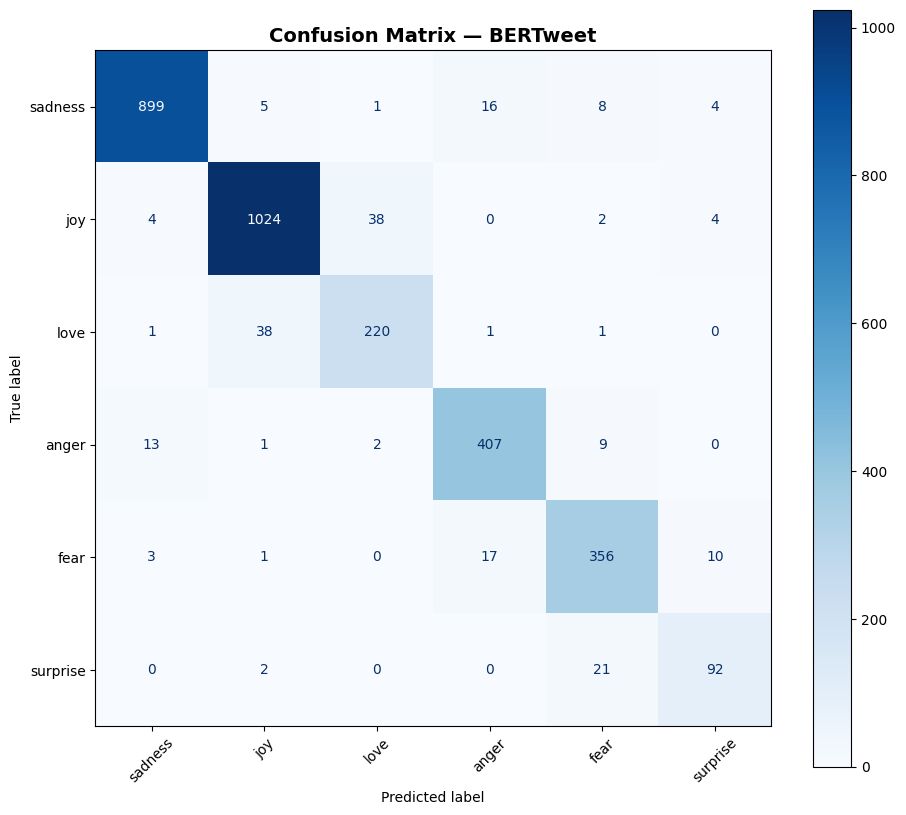

In [16]:
cm   = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(max(5, NUM_LABELS * 1.6), max(4, NUM_LABELS * 1.4)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, colorbar=True, cmap="Blues", xticks_rotation=45)
ax.set_title("Confusion Matrix — BERTweet", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()


## 14. Explainable AI — LIME

### Why Explainability Matters in NLP

Transformer models are high-capacity black boxes. Explainability tools allow us to:
- **Audit** whether the model relies on meaningful linguistic features (not spurious patterns like author names or formatting)
- **Diagnose** systematic errors and biases
- **Build trust** with domain experts and stakeholders
- Satisfy academic and regulatory requirements for model transparency

### LIME vs. SHAP for Transformers

| | LIME | SHAP (DeepSHAP / GradientSHAP) |
|---|---|---|
| Background dataset | Not required | Required |
| Speed | Fast | Slow for large models |
| Token-level support | Via word masking | Requires custom implementation |
| Stability | Varies per run | More stable |

**LIME** is the practical choice here: it treats the model as a pure black box via a `predict_proba` wrapper, requires no background dataset, and works natively with any HF tokenizer + model combination.

### Limitations of LIME for Transformers
- Explanations are **local** — valid only near the explained input
- LIME removes words independently, ignoring self-attention dependencies
- Results vary between runs due to random perturbation sampling
- Word-level granularity misses subword tokenisation effects


In [17]:
# ── Prediction wrapper for LIME ───────────────────────────────────────────────
def bertweet_predict_proba(texts):
    """Return softmax probability arrays (N, num_labels) for a list of strings."""
    model.eval()
    all_probs = []
    with torch.no_grad():
        for text in texts:
            enc = tokenizer(
                text,
                truncation=True,
                max_length=MAX_LEN,
                padding="max_length",
                return_tensors="pt",
            )
            enc    = {k: v.to(DEVICE) for k, v in enc.items()}
            logits = model(**enc).logits
            probs  = torch.softmax(logits, dim=-1).cpu().numpy()[0]
            all_probs.append(probs)
    return np.array(all_probs)

explainer = LimeTextExplainer(class_names=CLASS_NAMES, random_state=SEED)

# ── Explain 3 validation samples ─────────────────────────────────────────────
np.random.seed(SEED)
sample_idx = np.random.choice(len(val_df), size=min(3, len(val_df)), replace=False)

for i, idx in enumerate(sample_idx, 1):
    text_sample   = val_df.loc[idx, "text"]
    true_label    = CLASS_NAMES[val_df.loc[idx, "label"]]
    pred_label_i  = CLASS_NAMES[y_pred[idx]]
    pred_class_id = int(y_pred[idx])

    print(f"\n{'='*65}")
    print(f"Sample {i}")
    print(f"  Text (first 200 chars) : {text_sample[:200]}")
    print(f"  True label             : {true_label}")
    print(f"  Predicted label        : {pred_label_i}")

    exp = explainer.explain_instance(
        text_sample,
        bertweet_predict_proba,
        num_features=10,
        num_samples=200,
        labels=list(range(NUM_LABELS)),
    )

    print(f"  Top influential words for class '{pred_label_i}':")
    for word, weight in exp.as_list(label=pred_class_id):
        bar = "▓" * int(abs(weight) * 50)
        direction = "+" if weight > 0 else "-"
        print(f"    [{direction}] {word:25s} {weight:+.4f}  {bar}")

    try:
        exp.show_in_notebook(text=True, labels=(pred_class_id,))
    except Exception:
        pass



Sample 1
  Text (first 200 chars) : im sure ive got it right and my state of unencumberedness despite many years of feeling like i couldnt keep up anybody else is causing me to see my life as charmed
  True label             : joy
  Predicted label        : joy
  Top influential words for class 'joy':
    [+] charmed                   +0.5588  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
    [+] sure                      +0.1422  ▓▓▓▓▓▓▓
    [-] feeling                   -0.0798  ▓▓▓
    [-] couldnt                   -0.0652  ▓▓▓
    [-] im                        -0.0590  ▓▓
    [-] me                        -0.0569  ▓▓
    [+] up                        +0.0565  ▓▓
    [+] and                       +0.0545  ▓▓
    [-] keep                      -0.0524  ▓▓
    [-] causing                   -0.0481  ▓▓

Sample 2
  Text (first 200 chars) : i feel these people are utterly useless in my view
  True label             : sadness
  Predicted label        : sadness
  Top influential words for class 'sadness':
 

## 15. Discussion

**Performance**: This is the strongest fit for BERTweet. Short, informal emotional sentences closely resemble tweet language, giving BERTweet a genuine pre-training advantage over standard BERT.

**Class imbalance**: Joy and sadness typically account for ~50% of samples combined, while surprise and love are underrepresented. The confusion matrix will likely show lower recall on rare classes.

**Metric choice**: Weighted F1 is reported as the primary metric because it accounts for class imbalance. Macro F1 is also worth monitoring to evaluate fairness across all classes.

**BERTweet suitability**: High — the best fit among the three datasets.

**Expected confusion pairs**: joy ↔ love (both positive affect); fear ↔ sadness (both negative affect).


## 16. Conclusion and Future Improvements

BERTweet is well-suited for the `dair-ai/emotion` dataset. Short, emotionally expressive informal text aligns naturally with tweet pre-training.

**Future improvements:**
- Apply **class-weighted cross-entropy** to improve recall on rare classes (love, surprise)
- Use **macro F1** as the primary metric to penalise poor performance on rare classes
- Experiment with `bertweet-large` for higher capacity
- Data augmentation (back-translation, EDA) for underrepresented classes
- Early stopping with patience=2 on validation macro-F1
- Hierarchical classification: positive/negative → specific emotion
